<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong> August 11, 2025 <strong>Author:</strong> Adnan Alaref
</div>

## Computer Vision Libraries in PyTorch

Before we get started writing code, let's talk about some PyTorch computer vision libraries you should be aware of.

| **PyTorch Module**                  | **What Does It Do?**                                                                                                                                          |
|------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `torchvision`                      | Contains datasets, model architectures, and image transformations often used for computer vision problems.                                                  |
| `torchvision.datasets`            | Includes many example computer vision datasets for tasks like image classification, object detection, image captioning, video classification, and more.     |
| `torchvision.models`              | Provides commonly used and well-performing computer vision model architectures implemented in PyTorch.                                                      |
| `torchvision.transforms`          | Contains common image transformations (e.g., preprocessing, augmentation) used to prepare images for models.                                                |
| `torch.utils.data.Dataset`        | Base dataset class for PyTorch.                                                                                                                              |
| `torch.utils.data.DataLoader`     | Creates a Python iterable over a dataset (usually built using `torch.utils.data.Dataset`).                                                                  |

> **Note:**  
> The `torch.utils.data.Dataset` and `torch.utils.data.DataLoader` classes aren't limited to computer vision. They support many different types of data.


## 📝**Note: we will use function accuracy_fn() this function had implemented by Daniel Bourke helper_functions.py**

In [1]:
import requests
from pathlib import Path
# Download helper functions from github repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py alrady exits")
else:
  print("Downloding Helper_functions.py, Done....")

  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

Downloding Helper_functions.py, Done....


# **◍ Step 1: Import Required Librares.**

In [2]:
import torch
import random
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
from tqdm.auto import tqdm
from torchvision import datasets
from torch.utils.data import DataLoader
from helper_functions import accuracy_fn
from torchvision.transforms import ToTensor

import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')
# Ignore all FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)
print(f"PyTorch Version: {torch.__version__}\nTorchvision version: {torchvision.__version__}")

PyTorch Version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124


# **◍ Step 2: Prepare the Dataset.**

## torchvision.datasets and FashionMNIST

The `torchvision.datasets` module contains a lot of example datasets you can use to **practice writing computer vision code**. One of the most commonly used is `FashionMNIST`.

FashionMNIST is a dataset of grayscale images of clothing items. It has **10 different image classes**, making it a **multi-class classification** problem.

Later, we'll be building a computer vision neural network to identify the different styles of clothing in these images.

PyTorch has many popular vision datasets stored in `torchvision.datasets`, including `FashionMNIST`.

To use `torchvision.datasets.FashionMNIST()`, you need to provide the following parameters:

| **Parameter**           | **Type**                | **Description**                                                                 |
|-------------------------|-------------------------|---------------------------------------------------------------------------------|
| `root`                  | `str`                   | Folder where the data should be downloaded.                                     |
| `train`                 | `bool`                  | Whether to load the training split (`True`) or test split (`False`).            |
| `download`              | `bool`                  | Whether to download the dataset if it's not already available.                  |
| `transform`             | `torchvision.transforms`| Transformations to apply to the images (e.g., `ToTensor()`, normalization).     |
| `target_transform`      | Custom function or transform | (Optional) Transformation to apply to the target labels.                   |


In [3]:
# Setup training data
train_data = datasets.FashionMNIST(
  root="data", # where save data
  train=True, # downloading traing data
  download=True, # download data if not exist in disk
  transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
  target_transform=None # I need the labels as integer so just omit it Or leave it as defult
)

# Setup testing data
test_data = datasets.FashionMNIST(
  root="data", # where save data
  train=False, # downloading testing data
  download=True, # download data if not exist in disk
  transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.63MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.77MB/s]


In [4]:
img,label = train_data[0]
print(f"Image as tensor\n{img.ravel()[:150]}")
print(f"Image Lable: {label}")

Image as tensor
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
        0.0510, 0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0039, 

In [5]:
print(f"Image Shape: {img.shape}")

Image Shape: torch.Size([1, 28, 28])


## CHW vs HWC: Tensor Shape in Computer Vision

The order of our current image tensors is commonly referred to as **CHW**:

- **C**: Color Channels  
- **H**: Height  
- **W**: Width  

---

### 🆚 CHW vs HWC

| Format | Description               | Example Shape (1 image) |
|--------|---------------------------|--------------------------|
| CHW    | Channels First            | `[1, 28, 28]`            |
| HWC    | Channels Last             | `[28, 28, 1]`            |

There's ongoing debate in the deep learning community about whether image tensors should be represented in **CHW** (channels first) or **HWC** (channels last).

---

### 📦 NCHW and NHWC for Batches

You'll also encounter **NCHW** and **NHWC** formats, where:

- **N** = Number of images (batch size)  
- Example: For `batch_size = 32`, your shape could be:
  - **NCHW**: `[32, 1, 28, 28]`
  - **NHWC**: `[32, 28, 28, 1]`

---

### 🧠 PyTorch Behavior

- PyTorch **defaults to NCHW** for most operations.
- However, PyTorch documentation notes that **NHWC (channels last)** format can **perform better** on modern hardware and is considered [**best practice**](https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice) in many cases.

---

> **Note:**  
> Since our dataset and models are relatively small, the difference between NCHW and NHWC won't have a big impact for now.


## **🔸 Step 2.1: Get insights from Dataset.**

In [6]:
# How many samples are there?
len(train_data), len(train_data.targets), len(test_data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [7]:
# See classes
classes_names = train_data.classes
classes_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
print(f"Train Data Targets: {train_data.targets}\nUnique Targets: {train_data.targets.unique()}")

Train Data Targets: tensor([9, 0, 0,  ..., 3, 0, 5])
Unique Targets: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


## **🔸 Step 2.2: Let's Visulaize**

Image shape: torch.Size([1, 28, 28])


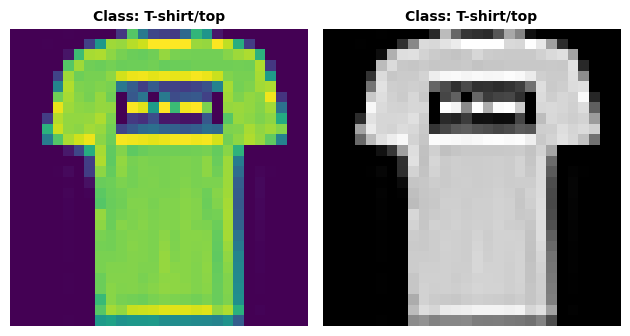

In [10]:
image ,label = train_data[1]
print(f"Image shape: {image.shape}")
plt.subplot(1,2,1)
plt.imshow(image.squeeze())
plt.title(f"Class: {train_data.classes[label]}", fontsize=10, weight='bold')
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Class: {train_data.classes[label]}", fontsize=10, weight='bold')
plt.axis("off")

plt.tight_layout()
plt.show()

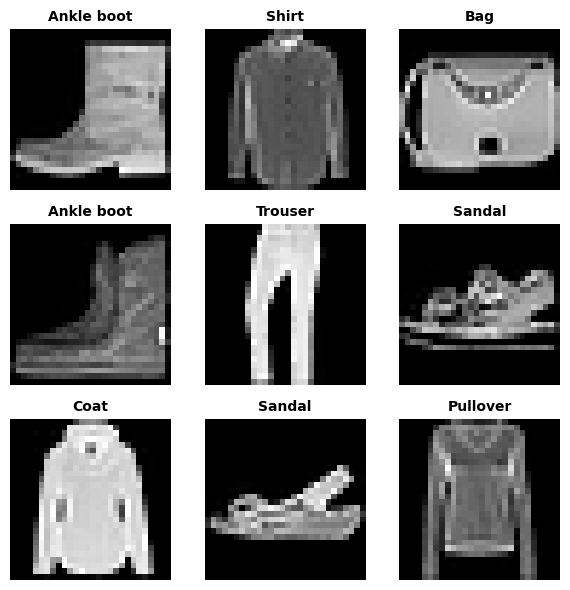

In [11]:
torch.manual_seed(42)
fig = plt.figure(figsize=(6,6))
row ,col = 3, 3
for i in range(1,10):
  idx = torch.randint(low=0, high=len(train_data), size=(1,)).item()
  img, label = train_data[idx]
  ax = fig.add_subplot(row,col,i)
  ax.set_title(train_data.classes[label],fontsize=10, weight='bold')
  ax.imshow(img.squeeze(), cmap='gray')
  ax.axis("off")

plt.tight_layout()
plt.show()

# **◍ Step 3: Prepare the DataLoader.**

In [12]:
# Setup the batch size hyperparameter
TRAIN_BATCH_SIZE = 32
TEST_BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=TEST_BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {TRAIN_BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {TEST_BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d617ce172d0>, <torch.utils.data.dataloader.DataLoader object at 0x7d617c4c76d0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [13]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [14]:
# Check out what's inside the training dataloader
test_features_batch, test_labels_batch = next(iter(test_dataloader))
test_features_batch.shape, test_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

# **◍ Step 4: Define the Model version 0.**

In [15]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
device

'cpu'

In [16]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self, in_dim, hidden_dim, out_dim):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # neural networks like their inputs in vector form
        nn.Linear(in_features=in_dim, out_features=hidden_dim),
        nn.Linear(in_features=hidden_dim, out_features=out_dim)
    )

  def forward(self,x):
    return self.layer_stack(x)

# Create Instance from model
FashionModelv0 = FashionMNISTModelV0(
                                  in_dim=28*28,
                                  hidden_dim=15,
                                  out_dim=len(classes_names)).to(device)
FashionModelv0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=15, bias=True)
    (2): Linear(in_features=15, out_features=10, bias=True)
  )
)

In [17]:
next(FashionModelv0.parameters()).device

device(type='cpu')

In [18]:
FashionModelv0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0050,  0.0275,  0.0053,  ..., -0.0198, -0.0060, -0.0241],
                      [ 0.0349, -0.0072,  0.0142,  ..., -0.0173, -0.0047, -0.0304],
                      [ 0.0081,  0.0005,  0.0217,  ...,  0.0322,  0.0322,  0.0071],
                      ...,
                      [ 0.0271,  0.0144,  0.0209,  ..., -0.0248, -0.0093, -0.0285],
                      [ 0.0108,  0.0197, -0.0351,  ..., -0.0032,  0.0172, -0.0038],
                      [ 0.0128, -0.0140,  0.0277,  ...,  0.0256, -0.0003,  0.0135]])),
             ('layer_stack.1.bias',
              tensor([-0.0033, -0.0350,  0.0029, -0.0008, -0.0220,  0.0348, -0.0286, -0.0303,
                      -0.0256, -0.0324, -0.0072, -0.0191,  0.0293,  0.0191,  0.0170])),
             ('layer_stack.2.weight',
              tensor([[ 0.2218, -0.2132, -0.1551,  0.2177,  0.1880,  0.0408,  0.1444,  0.0661,
                       -0.0195, -0.0864,  0.0906, -0.2097,  0.2545, -0.2278, 

## **🔸 Step 4.1: Setup Loss Function and Optimizer For Model Version 0.**

In [19]:
# Setup Loss Function
criterion = nn.CrossEntropyLoss()

# Set up Optimizer
optimizer = torch.optim.AdamW(params=FashionModelv0.parameters(), lr=0.01, weight_decay = 1e-4)

## **🔸 Step 4.2: Create Traning & Testing Loop.**

In [20]:
from typing import Any

def to_device(data: Any, device:torch.device) ->Any:
  """
    Recursively moves tensors in a nested structure to the specified device.

    Args:
        data (Any): The input data which can be a tensor, list, tuple, dict, or other objects.
        device (torch.device or str): The target device (e.g., 'cuda' or 'cpu').

    Returns:
        Any: The same structure as input, but with all tensors moved to the specified device.
    """
  if torch.is_tensor(data):
    return data.to(device)
  elif isinstance(data,(list,tuple)):
    return type(data)(to_device(x,device) for x in data)
  elif isinstance(data,dict):
    return {k:to_device(v,device) for k,v in data.items()}
  else:
    return data # Non-tensor types (e.g., int, str) remain unchanged

In [21]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    random.seed(seed)
    np.random.seed(seed)

In [22]:
# Set seed
set_seed(42)

epochs = 10
epoch_count = []
test_loss_values = []
train_loss_values = []

for epoch in tqdm(range(epochs), desc="Training Epochs"):

  FashionModelv0.train()
  total_train_loss,train_acc = 0,0

  for train_imgs,train_labels in train_dataloader:
    train_imgs,train_labels = to_device((train_imgs,train_labels),device)

    # Forward Pass
    train_logits = FashionModelv0(train_imgs)
    train_preds = torch.softmax(train_logits,dim=1).argmax(dim=1)


    # Loss and accuracy (per batch)
    train_loss = criterion(train_logits,train_labels)
    total_train_loss+=train_loss.item() # accumulatively add up the loss per epoch
    train_acc += accuracy_fn(y_true = train_labels, y_pred = train_preds)

    # Backward pass
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

  # Average loss,acc per batch per epoch
  train_acc /=len(train_dataloader)
  total_train_loss /=len(train_dataloader)

  # --- EVALUATE ON TEST SET ---
  FashionModelv0.eval()
  total_test_loss, test_acc = 0,0

  with torch.inference_mode():
    for test_imgs,test_labels in test_dataloader:
      test_imgs,test_labels = to_device((test_imgs,test_labels),device)

      # Forward pass
      test_logits = FashionModelv0(test_imgs)
      test_preds = test_logits.argmax(dim=1)

      # # Loss and accuracy (per batch)
      test_loss = criterion(test_logits,test_labels)
      total_test_loss+=test_loss.item()
      test_acc += accuracy_fn(y_true = test_labels,y_pred = test_preds) # not need softmax

    test_acc/=len(test_dataloader)
    total_test_loss /= len(test_dataloader)

  epoch_count.append(epoch+1)
  test_loss_values.append(total_test_loss)
  train_loss_values.append(total_train_loss)

  print(f"Epoch {epoch+1:>2} - Train loss: {total_train_loss:.3f} | Train acc: {train_acc:.3f}% | Test loss: {total_test_loss:.3f} | Test acc: {test_acc:.3f}%")

Training Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1 - Train loss: 0.576 | Train acc: 79.967% | Test loss: 0.534 | Test acc: 81.210%
Epoch  2 - Train loss: 0.515 | Train acc: 82.408% | Test loss: 0.496 | Test acc: 82.977%
Epoch  3 - Train loss: 0.494 | Train acc: 83.062% | Test loss: 0.552 | Test acc: 81.480%
Epoch  4 - Train loss: 0.491 | Train acc: 83.192% | Test loss: 0.559 | Test acc: 82.149%
Epoch  5 - Train loss: 0.484 | Train acc: 83.597% | Test loss: 0.550 | Test acc: 82.438%
Epoch  6 - Train loss: 0.480 | Train acc: 83.612% | Test loss: 0.545 | Test acc: 81.400%
Epoch  7 - Train loss: 0.471 | Train acc: 83.972% | Test loss: 0.520 | Test acc: 82.817%
Epoch  8 - Train loss: 0.475 | Train acc: 83.890% | Test loss: 0.522 | Test acc: 82.318%
Epoch  9 - Train loss: 0.471 | Train acc: 83.993% | Test loss: 0.553 | Test acc: 82.508%
Epoch 10 - Train loss: 0.465 | Train acc: 84.182% | Test loss: 0.513 | Test acc: 82.867%


## **🔸 Step 4.3: Let's Evaluate our model.**

In [23]:
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               criterion:torch.nn.Module, accuracy_fn, device: torch.device = device):
  """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        criterion (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
  """
  model.eval()
  test_loss, acc=0, 0
  with torch.inference_mode():
    for X,y in tqdm(data_loader, desc="Testing Epochs:"):
      x, y = to_device((X,y),device)

      # Forward Pass
      y_logits = model(X)
      y_preds = y_logits.argmax(dim=1)

      # Calc Loss and acc
      loss = criterion(y_logits, y)
      test_loss +=loss.item()
      acc += accuracy_fn(y_true = y ,y_pred=y_preds)

    test_loss /=len(data_loader)
    acc /=len(data_loader)

  return {"Model_name":model.__class__.__name__,
          "Model_accuracy":round(acc,2),
          "Model_loss": round(test_loss,4)}

In [24]:
FashionModelv0_results = eval_model(model=FashionModelv0,
                           data_loader=test_dataloader,
                           criterion=criterion, accuracy_fn=accuracy_fn, device = device)
FashionModelv0_results

Testing Epochs::   0%|          | 0/313 [00:00<?, ?it/s]

{'Model_name': 'FashionMNISTModelV0',
 'Model_accuracy': 82.87,
 'Model_loss': 0.5126}

## **🔸 Step 4.4: Let's Visualize our model.**

In [25]:
def Display_train_test_loss_curve(epochs,train_losses,test_losses):
  plt.figure(figsize=(6,5) ,dpi=100)
  plt.plot(epochs,train_losses,label = "Train Loss")
  plt.plot(epochs ,test_losses, label = "Test Loss")
  plt.ylabel("Loss" ,fontsize = 12 ,weight='bold')
  plt.xlabel("Epochs" ,fontsize = 12 ,weight='bold')
  plt.title(f"Traning and Testing Loss Curves" ,fontsize = 12 ,weight='bold')
  plt.legend(prop = {"size":14},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # plt.axis("off")
  plt.show()

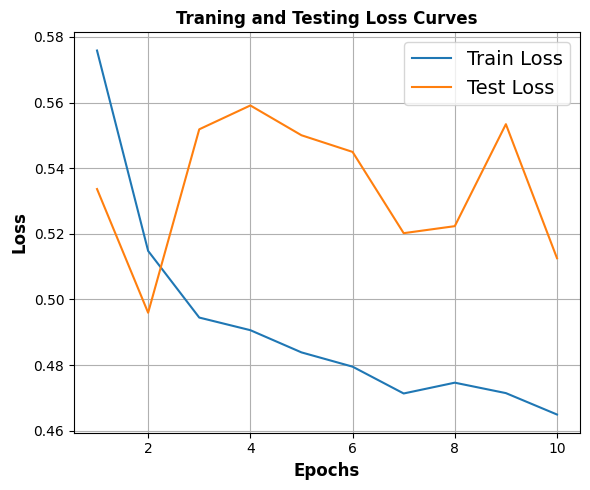

In [26]:
Display_train_test_loss_curve(epoch_count,train_loss_values,test_loss_values)

# **◍ Step 5: Improvment The Model by add Non-Linearity.**

## **🔸 Step 5.1: Build our model version1.**

In [27]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, in_dim, hidden_dim, out_dim):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # flatten inputs into single vector
        nn.Linear(in_features=in_dim, out_features=hidden_dim),
        nn.ReLU(),
        nn.Linear(in_features=hidden_dim, out_features=out_dim),
        nn.ReLU()
      )

  def forward(self, x:torch.tensor):
    return self.layer_stack(x)

# Create Instance from Our Model
FashionModelv1 = FashionMNISTModelV1(in_dim=28*28,
                                     hidden_dim=64,
                                     out_dim=len(classes_names)).to(device)
FashionModelv1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [28]:
next(FashionModelv1.parameters())

Parameter containing:
tensor([[ 0.0109, -0.0074,  0.0296,  ..., -0.0130,  0.0051, -0.0066],
        [ 0.0168,  0.0327,  0.0128,  ...,  0.0164,  0.0230, -0.0205],
        [-0.0095,  0.0086, -0.0254,  ..., -0.0169, -0.0249,  0.0134],
        ...,
        [-0.0099, -0.0229, -0.0101,  ..., -0.0072, -0.0356, -0.0195],
        [ 0.0081,  0.0098,  0.0235,  ..., -0.0251,  0.0259, -0.0259],
        [ 0.0046, -0.0299, -0.0018,  ..., -0.0258,  0.0013, -0.0085]],
       requires_grad=True)

In [29]:
next(FashionModelv1.parameters()).device

device(type='cpu')

In [30]:
FashionModelv1.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0109, -0.0074,  0.0296,  ..., -0.0130,  0.0051, -0.0066],
                      [ 0.0168,  0.0327,  0.0128,  ...,  0.0164,  0.0230, -0.0205],
                      [-0.0095,  0.0086, -0.0254,  ..., -0.0169, -0.0249,  0.0134],
                      ...,
                      [-0.0099, -0.0229, -0.0101,  ..., -0.0072, -0.0356, -0.0195],
                      [ 0.0081,  0.0098,  0.0235,  ..., -0.0251,  0.0259, -0.0259],
                      [ 0.0046, -0.0299, -0.0018,  ..., -0.0258,  0.0013, -0.0085]])),
             ('layer_stack.1.bias',
              tensor([ 0.0153, -0.0271,  0.0138, -0.0198, -0.0131,  0.0262,  0.0122, -0.0236,
                       0.0173,  0.0106, -0.0110, -0.0352,  0.0172,  0.0203,  0.0189,  0.0136,
                       0.0044, -0.0286, -0.0246, -0.0055,  0.0105, -0.0019, -0.0177,  0.0149,
                       0.0066, -0.0257,  0.0283,  0.0189,  0.0284, -0.0100,  0.0172,  0.0065,
                

## **🔸 Step 5.2: Setup loss and optimizer For Model version 1.**

In [31]:
loss_fn_v1 = nn.CrossEntropyLoss()
optimizer_v1 = torch.optim.AdamW(params=FashionModelv1.parameters(), lr = 0.01 , weight_decay=1e-4)

## **🔸 Step 5.3: Create General Traning & Testing Loop.**

In [32]:
def train_step(model: nn.Module,
                 dataloader: torch.utils.data.DataLoader,
                 accuracy_fn, criterion: torch.nn.Module,
                 optimizer : torch.optim.Optimizer, device: torch.device=device):
  """Trains a PyTorch model using the provided data loader and returns a dictionary of training results.

  Args:
      model (torch.nn.Module): The PyTorch model to be trained.
      data_loader (torch.utils.data.DataLoader): DataLoader providing batches of training data.
      accuracy_fn (Callable): A function to calculate accuracy, comparing model predictions to true labels.
      optimizer (torch.optim.Optimizer): The optimization algorithm used to update model parameters.
      criterion (torch.nn.Module): The loss function used to compute the error between predictions and targets.
      device (torch.device): The device (CPU or GPU) on which the model and data should be loaded.

     Returns:
      dict: A dictionary containing training statistics such as model_name,loss and accuracy ber batch for each epoch.
  """
  total_train_loss, train_acc = 0,0
  model = to_device(model,device)
  model.train()

  for X, y in dataloader:
    # Set batch in target device
    X, y = to_device((X,y),device)

    # Forward Pass
    y_logits = model(X)
    train_preds = torch.softmax(y_logits,dim=1).argmax(dim=1) # Go from logits -> pred labels

    # Clac Loss and accuracy
    train_loss = criterion(y_logits,y)
    total_train_loss +=train_loss.item()
    train_acc +=accuracy_fn(y_true=y, y_pred=train_preds)

    # Backward Pass
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

  # Average Loss and accuracy for all batches per epoch
  total_train_loss/=len(dataloader)
  train_acc/=len(dataloader)

  return {
    "Model_name":model.__class__.__name__,
    "Train_accuracy":round(train_acc,3),
    "Train_loss":total_train_loss
  }

In [33]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              accuracy_fn, criterion:torch.nn.Module, device:torch.device = device):
  """Evaluate a PyTorch model using the provided data loader and returns a dictionary of evaluting results.

  Args:
      model (torch.nn.Module): The PyTorch model to be trained.
      data_loader (torch.utils.data.DataLoader): DataLoader providing batches of evaluing data.
      accuracy_fn (Callable): A function to calculate accuracy, comparing model predictions to true labels.
      criterion (torch.nn.Module): The loss function used to compute the error between predictions and targets.
      device (torch.device): The device (CPU or GPU) on which the model and data should be loaded.

     Returns:
      dict: A dictionary containing testing statistics such as model_name, loss and accuracy ber batch for each epoch.
  """
  total_test_loss,test_acc = 0, 0
  model = to_device(model,device)
  model.eval()
  with torch.inference_mode():
    for X, y in dataloader:
      X, y = to_device((X,y) ,device)

      # Forward Pass
      test_logits = model(X)
      test_preds = torch.softmax(test_logits,dim=1).argmax(dim=1)

      # Calc Loss
      test_loss = criterion(test_logits,y)
      total_test_loss+=test_loss.item()
      test_acc += accuracy_fn(y_true=y, y_pred=test_preds)

    total_test_loss /= len(dataloader)
    test_acc /=len(dataloader)

  return {
    "Model_name":model.__class__.__name__,
    "Test_accuracy":round(test_acc,3),
    "Test_loss":total_test_loss
  }

## **🔸 Step 5.4: Traning & Testing Model.**

In [34]:
set_seed(42)

epochs = 10
test_phase = {}
train_phase = {}

epoch_count = []
test_loss_values =[]
train_loss_values = []

for epoch in tqdm(range(epochs), desc = "Training Epochs :"):
  train_phase = train_step(model=FashionModelv1,
                            dataloader=train_dataloader,
                            accuracy_fn=accuracy_fn,
                            optimizer=optimizer_v1,
                            criterion=loss_fn_v1,
                            device=device)

  test_phase = test_step(model=FashionModelv1,
                         dataloader=test_dataloader,
                         accuracy_fn=accuracy_fn,
                         criterion=loss_fn_v1,)

  epoch_count.append(epoch)
  test_loss_values.append(test_phase["Test_loss"])
  train_loss_values.append(train_phase["Train_loss"])

  print(f"Epoch {epoch+1:>2} - Train loss: {train_phase['Train_loss']:.3f} | Train acc: {train_phase['Train_accuracy']:.3f}% | Test loss: {test_phase['Test_loss']:.3f} | Test acc: {test_phase['Test_accuracy']:.3f}%")

Training Epochs ::   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1 - Train loss: 1.149 | Train acc: 60.108% | Test loss: 1.059 | Test acc: 62.181%
Epoch  2 - Train loss: 1.061 | Train acc: 62.363% | Test loss: 1.086 | Test acc: 61.532%
Epoch  3 - Train loss: 1.039 | Train acc: 62.960% | Test loss: 1.082 | Test acc: 62.410%
Epoch  4 - Train loss: 1.026 | Train acc: 63.255% | Test loss: 1.070 | Test acc: 62.360%
Epoch  5 - Train loss: 1.026 | Train acc: 63.320% | Test loss: 1.054 | Test acc: 62.111%
Epoch  6 - Train loss: 1.014 | Train acc: 63.522% | Test loss: 1.073 | Test acc: 62.181%
Epoch  7 - Train loss: 1.013 | Train acc: 63.582% | Test loss: 1.066 | Test acc: 62.370%
Epoch  8 - Train loss: 1.004 | Train acc: 63.752% | Test loss: 1.074 | Test acc: 62.310%
Epoch  9 - Train loss: 1.003 | Train acc: 63.825% | Test loss: 1.054 | Test acc: 62.360%
Epoch 10 - Train loss: 1.003 | Train acc: 63.825% | Test loss: 1.094 | Test acc: 62.810%


In [35]:
FashionModelv1_results = eval_model(model=FashionModelv1,
                                    data_loader=test_dataloader,
                                    criterion=loss_fn_v1, accuracy_fn=accuracy_fn, device = device)
FashionModelv1_results

Testing Epochs::   0%|          | 0/313 [00:00<?, ?it/s]

{'Model_name': 'FashionMNISTModelV1',
 'Model_accuracy': 62.81,
 'Model_loss': 1.0939}

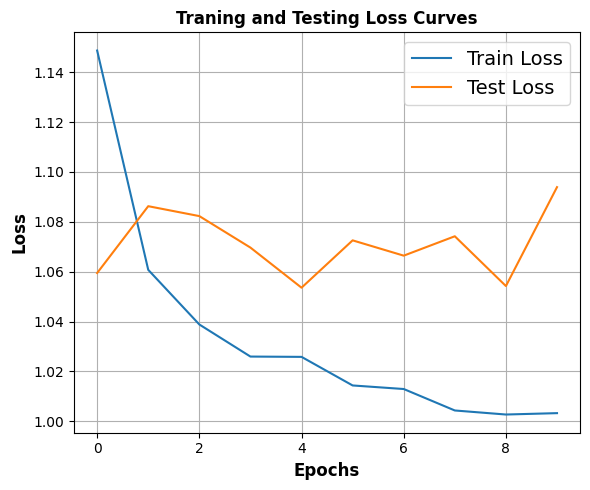

In [36]:
Display_train_test_loss_curve(epoch_count,train_loss_values,test_loss_values)

# **◍ Step 6: Improvment the model by add a Convolutional Neural Network. (CNN)**

## **🔸 Step 6.1: Build our model version2.**

In [37]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, in_dim:int, hidden_dim:int, out_dim:int):
    super(FashionMNISTModelV2, self).__init__()
    # 📥 Input: (1, 28, 28) ← 1 channel (grayscale)
    # 🧠 Hidden Layer 1 - Convolution + ReLU + Convolution + ReLU + MaxPool
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=in_dim,
                  out_channels=hidden_dim,
                  kernel_size = (3,3),
                  stride = 1,
                  padding = 1), # (B, 10, 28, 28)
        nn.ReLU(),# ReLU → no shape change
        nn.Conv2d(in_channels=hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size = (3,3,),
                  stride = 1,
                  padding = 1), # (B, 10, 28, 28)
        nn.ReLU(),# ReLU → no shape change
        nn.MaxPool2d(kernel_size=(2,2), stride=2) # (B, 10, 14, 14)
    )

    # 🧠 Hidden Layer 2 - Convolution + ReLU + Convolution + ReLU + MaxPool
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size=(3,3),
                  stride = 1,
                  padding = 1), # (B, 10, 14, 14)
        nn.ReLU(),# ReLU → no shape change
        nn.Conv2d(in_channels = hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size=(3,3),
                  stride = 1,
                  padding = 1), # (B, 10, 14, 14)
        nn.ReLU(), # ReLU → no shape change
        # ⚠️ In PyTorch, if stride is not provided, it defaults to kernel_size.
        nn.MaxPool2d(kernel_size=(2,2)) # (B, 10, 7, 7)
    )

    # 🧠 Hidden Layer 3 - Fully Connected
    self.fc1_block = nn.Sequential(
        # The output of conv_block_2 is 4D. Before passing to nn.Linear, you need to flatten it to 2D:
        nn.Flatten(), # Or x.view(x.size(0), -1)
        nn.Linear(in_features=hidden_dim *7*7, #*?*?
                  out_features=out_dim)
    )

  def forward(self, x:torch.tensor):
    x = self.conv_block_1(x)
    # print(f"Output shape of conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"Output shape of conv_block_2: {x.shape}")
    x = self.fc1_block(x)
    # print(f"Output shape of fc1_block: {x.shape}")
    return x

# Create Instance from Our Model
FashionModelv2 = FashionMNISTModelV2(in_dim=1,
                                     hidden_dim=10,
                                     out_dim=len(classes_names)).to(device)
FashionModelv2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (fc1_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [38]:
str(next(FashionModelv2.parameters()).device)

'cpu'

## **🔸 Step 6.2: Create One batch to check Model.**

In [39]:
# rand_image_tensor = torch.randn((1,1,28,28))
# print(f"Random tesor Shape [B, C, W, H]: {rand_image_tensor.shape}\n")

# # Check The Model
# print("Model Result:")
# FashionModelv2(rand_image_tensor)

## **🔸 Step 6.3: Setup Loss and Optimizer.**

In [40]:
loss_fn_v2 = nn.CrossEntropyLoss()
optimizer_v2 = torch.optim.AdamW(params=FashionModelv2.parameters(), lr=0.01, weight_decay=1e-4)

## **🔸 Step 6.4: Traning & Testing Model.**

In [41]:
set_seed(42)
test_history={}
train_history={}

epochs = 10
epoch_count = []
test_loss_values=[]
train_loss_values=[]

# Early stopping setup
best_model = None
best_acc = 0.0
patience = 3
cnt = 0

for epoch in tqdm(range(epochs), desc="Training Epochs:"):
  train_history = train_step(model=FashionModelv2,
                               dataloader = train_dataloader,
                               optimizer = optimizer_v2,
                               accuracy_fn=accuracy_fn,
                               criterion = loss_fn_v2,
                               device = device)

  test_history = test_step(model=FashionModelv2,
                           dataloader=test_dataloader,
                           accuracy_fn=accuracy_fn,
                           criterion=loss_fn_v2)

  epoch_count.append(epoch)
  test_loss_values.append(test_history["Test_loss"])
  train_loss_values.append(train_history["Train_loss"])

  # ---- Early Stopping ----
  print(f"Epoch {epoch+1:>2} - Train loss: {train_history['Train_loss']:.3f} | Train acc: {train_history['Train_accuracy']:.3f}% | Test loss: {test_history['Test_loss']:.3f} | Test acc: {test_history['Test_accuracy']:.3f}%")

  if test_history["Test_accuracy"]>best_acc:
    best_model = FashionModelv2.state_dict()
    best_acc = test_history["Test_accuracy"]
    cnt = 0
  else:
    cnt +=1
    print(f"⏳ No improvement... ({cnt}/{patience})")

  if cnt >= patience:
    print("⛔ Early stopping triggered.")
    break

Training Epochs::   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1 - Train loss: 0.474 | Train acc: 82.705% | Test loss: 0.393 | Test acc: 85.863%
Epoch  2 - Train loss: 0.379 | Train acc: 85.990% | Test loss: 0.395 | Test acc: 85.423%
⏳ No improvement... (1/3)
Epoch  3 - Train loss: 0.367 | Train acc: 86.537% | Test loss: 0.401 | Test acc: 85.224%
⏳ No improvement... (2/3)
Epoch  4 - Train loss: 0.359 | Train acc: 86.772% | Test loss: 0.375 | Test acc: 86.621%
Epoch  5 - Train loss: 0.353 | Train acc: 86.882% | Test loss: 0.371 | Test acc: 86.621%
⏳ No improvement... (1/3)
Epoch  6 - Train loss: 0.351 | Train acc: 86.993% | Test loss: 0.364 | Test acc: 86.781%
Epoch  7 - Train loss: 0.350 | Train acc: 87.140% | Test loss: 0.374 | Test acc: 86.012%
⏳ No improvement... (1/3)
Epoch  8 - Train loss: 0.350 | Train acc: 87.212% | Test loss: 0.375 | Test acc: 85.833%
⏳ No improvement... (2/3)
Epoch  9 - Train loss: 0.346 | Train acc: 87.073% | Test loss: 0.387 | Test acc: 85.873%
⏳ No improvement... (3/3)
⛔ Early stopping triggered.


In [42]:
# Load best model after training
FashionModelv2.load_state_dict(best_model)
print(f"\n✅ Best Test Accuracy Achieved: {best_acc:.4f}")


✅ Best Test Accuracy Achieved: 86.7810


In [43]:
FashionModelv2_results = eval_model(model=FashionModelv2,
                                    data_loader=test_dataloader,
                                    criterion =loss_fn_v2, accuracy_fn=accuracy_fn, device=device)
FashionModelv2_results

Testing Epochs::   0%|          | 0/313 [00:00<?, ?it/s]

{'Model_name': 'FashionMNISTModelV2',
 'Model_accuracy': 85.87,
 'Model_loss': 0.3874}

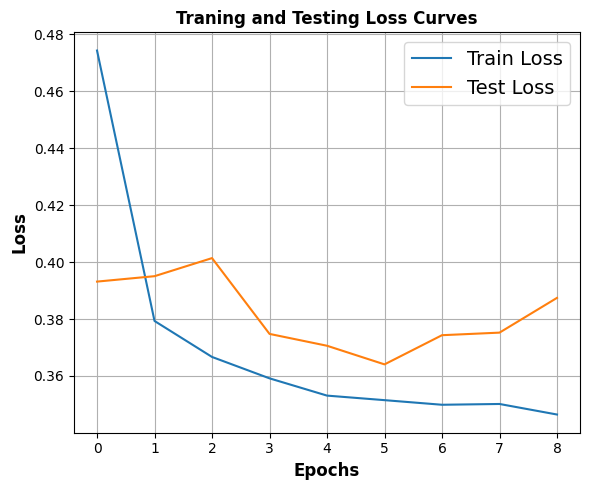

In [44]:
Display_train_test_loss_curve(epochs=epoch_count,train_losses=train_loss_values,test_losses=test_loss_values)

# **◍ Step 7: Compare Models Results.**

In [45]:
compare_model_results = pd.DataFrame([FashionModelv0_results,
                                      FashionModelv1_results,
                                      FashionModelv2_results])
compare_model_results.style.set_properties(**{'background-color':'#2a9d8f','color':'white','border':'2.5px solid black'})

,Model_name,Model_accuracy,Model_loss
0,FashionMNISTModelV0,82.870000,0.512600
1,FashionMNISTModelV1,62.810000,1.093900
2,FashionMNISTModelV2,85.870000,0.387400


In [46]:
print(compare_model_results.columns)
print(compare_model_results.index)

Index(['Model_name', 'Model_accuracy', 'Model_loss'], dtype='object')
RangeIndex(start=0, stop=3, step=1)


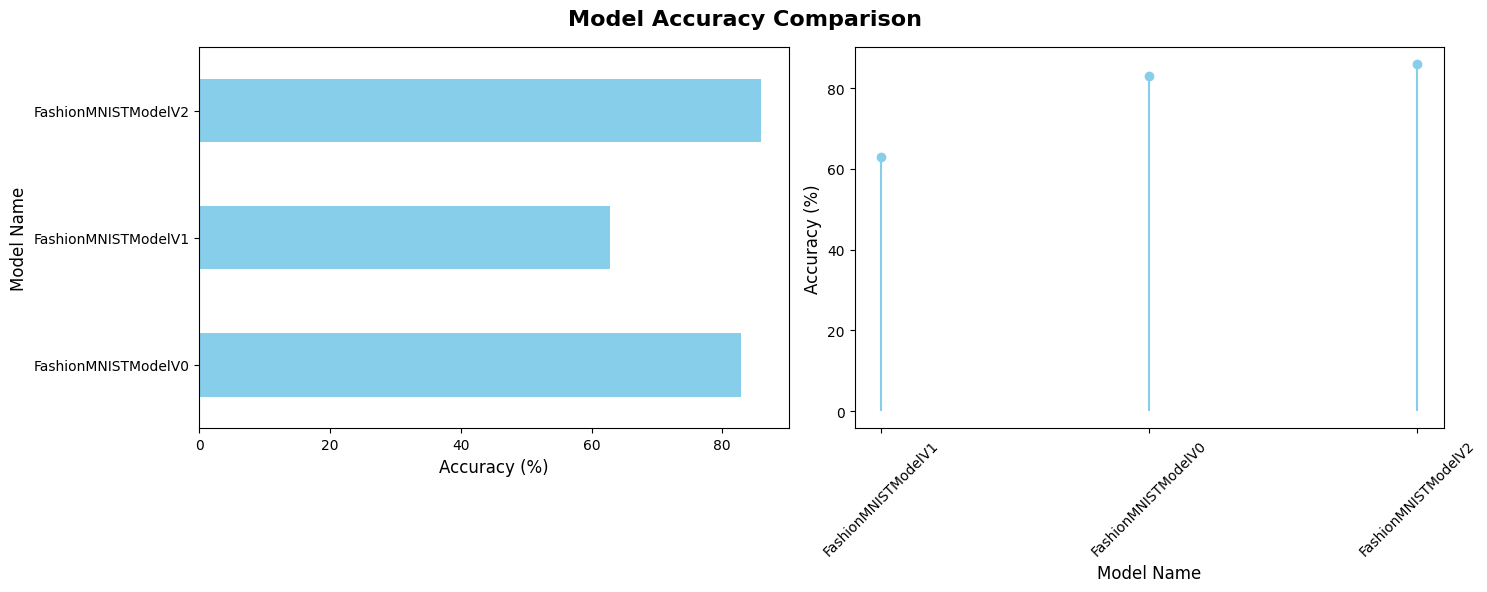

In [47]:
fig ,ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6), dpi=100)
fig.suptitle("Model Accuracy Comparison", fontsize=16, fontweight='bold')
# barh chart
compare_model_results.set_index("Model_name")["Model_accuracy"].plot(
  x="Model_name",
  y="Model_Accuracy",
  kind="barh",
  color="skyblue",
  legend=False,
  ax=ax[0]
)
ax[0].set_xlabel("Accuracy (%)", fontsize=12)
ax[0].set_ylabel("Model Name", fontsize=12)

# Lollipop chart
df = compare_model_results.sort_values("Model_accuracy")
ax[1].stem(df["Model_name"], df["Model_accuracy"], basefmt=" ", linefmt='skyblue', markerfmt='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_xlabel("Model Name", fontsize=12)
ax[1].set_ylabel("Accuracy (%)", fontsize=12)

plt.tight_layout()
plt.show()

## **🔸 Step 7.1: Evaluate Model on Sample of Data.**

In [48]:
def make_prediction(model:nn.Module,
                    data: list,
                    device:torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # prepare sample
      sample = torch.unsqueeze(sample,dim=0).to(device) # Add an extra dimension and send sample to device
      # Forward Pass
      logits = model(sample)

      # Get prediction probability (logit -> prediction probability)
      pred_prob = torch.softmax(logits.squeeze() , dim=0)

      # Get pred_prob off GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [49]:
test_data , type(test_data)

(Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor(),
 torchvision.datasets.mnist.FashionMNIST)

## **🔸 Step 7.2: Get Sample From Test Dataset.**

In [50]:
set_seed(42)
test_labels = []
test_samples = []

for sample , label in random.sample(population=list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} .-. ({classes_names[test_labels[0]]}) ")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 .-. (Sandal) 


In [51]:
pred_probs = make_prediction(model=FashionModelv2, data=test_samples, device=device)
pred_probs[:2]

tensor([[2.7272e-09, 1.1887e-14, 4.7544e-11, 5.0858e-14, 5.8000e-13, 9.9997e-01,
         1.6229e-10, 1.6811e-05, 3.5115e-07, 1.5888e-05],
        [4.4799e-03, 9.8049e-01, 2.2624e-04, 8.3376e-04, 1.1572e-03, 1.1459e-06,
         1.2768e-02, 9.0579e-08, 5.3334e-06, 3.7512e-05]])

In [52]:
# Get prediction lables
pred_lables = pred_probs.argmax(dim=0)
pred_lables , test_labels

(tensor([5, 8, 3, 4, 6, 0, 5, 7, 6, 2]), [5, 1, 7, 4, 3, 0, 4, 7, 1])

## **🔸 Step 7.3:Visulize Sample Prediction.**

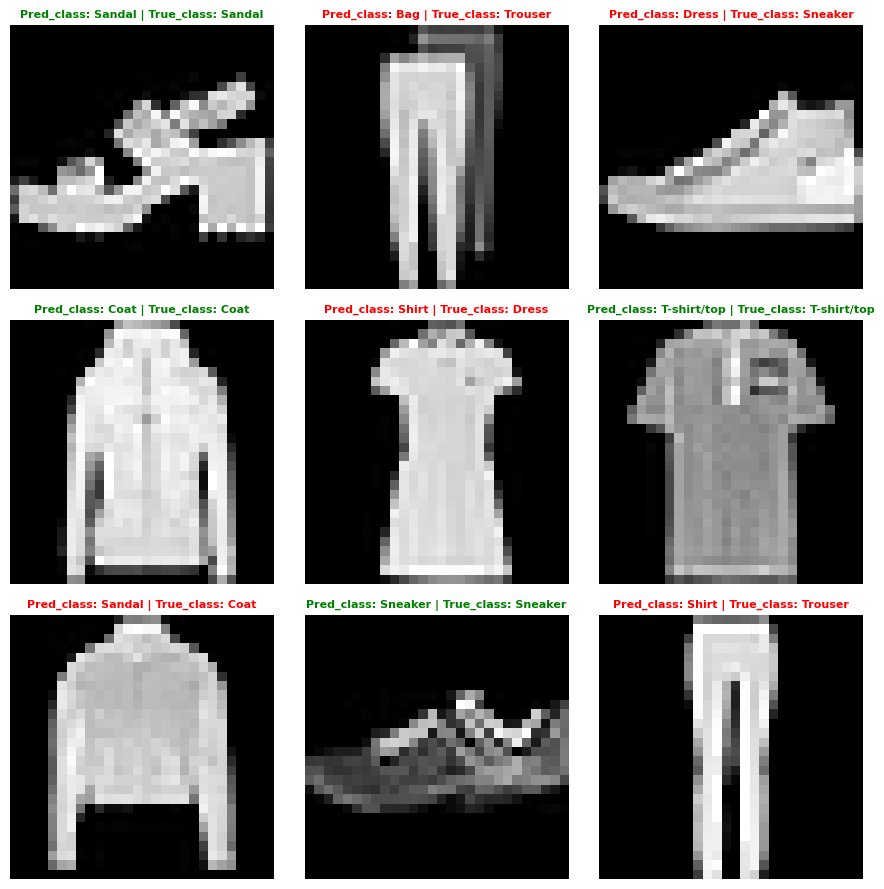

In [53]:
plt.figure(figsize=(9,9))
row, col = 3, 3

for i, sample in  enumerate(test_samples):
  # Create a subplot
  plt.subplot(row,col,i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

   # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = classes_names[pred_lables[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = classes_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred_class: {pred_label} | True_class: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
    plt.title(title_text, c='g', fontsize=8, weight='bold')
  else:
    plt.title(title_text, c='r', fontsize=8, weight='bold')
  plt.axis("off")

plt.tight_layout()
plt.show()

## **🔸 Step 7.4: Making a Confusion Matrix.**

In [54]:
len(test_dataloader.dataset) , len(test_dataloader.dataset.classes)

(10000, 10)

In [55]:
FashionModelv2.to(device)
FashionModelv2.eval()
y_preds = []

with torch.inference_mode():
  for X,_ in tqdm(test_dataloader, desc="Making predictions"):
    X = to_device((X),device)

    # Forward Pass
    logits = FashionModelv2(X)
    # Get probs
    y_pred = torch.softmax(logits, dim=1).argmax(dim=1)
    # Store predictions
    y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
y_preds_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

**Alright — here’s a `vectorized version` that avoids `append` and `cat` altogether by collecting predictions directly into one `preallocated` tensor, best for `large dataset`.**

In [56]:
FashionModelv2.to(device)
FashionModelv2.eval()

# Preallocate both predictions and probabilities
idx=0
total_samples = len(test_dataloader.dataset)
y_pred_tensor = torch.empty(total_samples, dtype=torch.long) # Class indices
y_prob_tensor = torch.empty(total_samples, len(classes_names), dtype=torch.long) # Probabilities

with torch.inference_mode():
  for X,_ in tqdm(test_dataloader, desc="Making predictions"):
    X = to_device((X),device)

    # Forward Pass
    logits = FashionModelv2(X)
    # Get probs
    probs = torch.softmax(logits, dim=1)

    # Get pred_labels
    y_pred_batch = probs.argmax(dim=1)
    # Store predictions
    batch_size = X.size(0)
    y_pred_tensor[idx:idx+batch_size] = y_pred_batch.cpu()
    y_prob_tensor[idx:idx+batch_size] = probs.cpu()

    idx+=batch_size

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

**How you can use them later:**
* **y_pred_tensor** → accuracy, confusion matrix, classification report.
* **y_probs_tensor** → ROC curves, PR curves, top-k accuracy, or plotting probability histograms.

In [57]:
# Let's plot Confusion Matrix by Using mlxtend
# 1- See if torchmetrics exists, if not, install it
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19,  "mlxtend verison should be 0.19.0 or higher"
except:
  # %%capture
  ! pip install torchmetrics > /dev/null 2>&1 && pip install -U mlxtend >/dev/null 2>&1
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


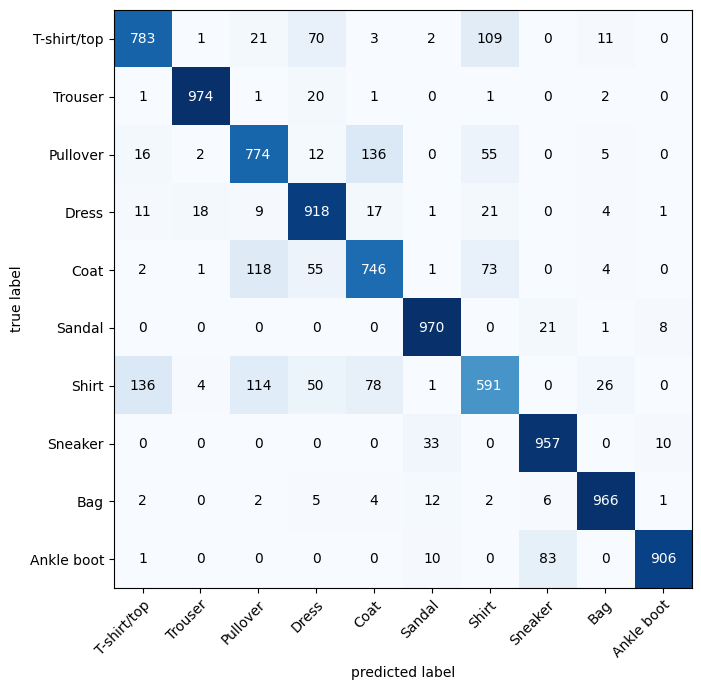

In [58]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(classes_names))
confmat_tensor = confmat(preds = y_pred_tensor, target= test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.cpu().numpy(), # matplotlib likes working with NumPy
                            class_names = classes_names,
                            figsize=(10,7))
plt.tight_layout()
plt.show()

From the confusion matrix, our model’s performance looks **generally strong** but with some **notable confusion between** visually similar clothing categories.

## ✅ Strong Performance
- **Trouser** → 977 correct, very few mistakes  
- **Sandal**, **Bag**, **Sneaker**, **Ankle boot** → mostly perfect classification  
- **Coat** and **Dress** → high accuracy but with some mix-ups  

## ⚠ Confusion Patterns
- **T-shirt/top ↔ Shirt** → Big confusion (150 T-shirts predicted as Shirts, 139 Shirts predicted as T-shirts)  
- **Pullover ↔ Coat** and **Pullover ↔ Shirt** → Significant overlap  
- **Dress ↔ Coat** and **Dress ↔ Pullover** → Some mix-up due to similar visual features  


# **◍ Step 8: Class-specific tuning**
>**Add a small fine-tuning stage focusing only on the confusing classes.**

## **🔸 Step 8.1: Find all confuized pairs.**

In [59]:
# We'll extract all pairs with their confusion counts from the given confusion matrix (cm)
pairs_confusion = []

for i in range(len(classes_names)):
  for j in range(len(classes_names)):
    if i!=j and confmat_tensor[i][j]>0:
      pairs_confusion.append(((i,j),confmat_tensor[i,j].item())) # only consider misclassifications

# Sort by confusion count descending
pairs_confusion.sort(key=lambda x:x[1], reverse=True)

# Map indices to labels
labels_map = train_data.classes

# Create DataFrame
confusion_df = pd.DataFrame([{"True class":labels_map[i],
                              "Pred class":labels_map[j],
                              "Count":count} for (i,j),count in pairs_confusion])

confusion_df.T.style.set_properties(**{'background-color':'#2a9d8f','color':'white','border':'2.5px solid black'})

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56
True class,Pullover,Shirt,Coat,Shirt,T-shirt/top,Ankle boot,Shirt,Coat,T-shirt/top,Pullover,Coat,Shirt,Sneaker,Shirt,T-shirt/top,Dress,Sandal,Trouser,Dress,Dress,Pullover,Pullover,Bag,T-shirt/top,Dress,Sneaker,Ankle boot,Dress,Sandal,Bag,Pullover,Bag,Dress,Coat,Shirt,Bag,T-shirt/top,T-shirt/top,Trouser,Pullover,Coat,Bag,Bag,Bag,T-shirt/top,Trouser,Trouser,Trouser,Trouser,Dress,Dress,Coat,Coat,Sandal,Shirt,Bag,Ankle boot
Pred class,Coat,T-shirt/top,Pullover,Pullover,Shirt,Sneaker,Coat,Shirt,Dress,Shirt,Dress,Dress,Sandal,Bag,Pullover,Shirt,Sneaker,Dress,Trouser,Coat,T-shirt/top,Dress,Sandal,Bag,T-shirt/top,Ankle boot,Sandal,Pullover,Ankle boot,Sneaker,Bag,Dress,Bag,Bag,Trouser,Coat,Coat,Sandal,Bag,Trouser,T-shirt/top,T-shirt/top,Pullover,Shirt,Trouser,T-shirt/top,Pullover,Coat,Shirt,Sandal,Ankle boot,Trouser,Sandal,Bag,Sandal,Ankle boot,T-shirt/top
Count,136,136,118,114,109,83,78,73,70,55,55,50,33,26,21,21,21,20,18,17,16,12,12,11,11,10,10,9,8,6,5,5,4,4,4,4,3,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1


## **🔸 Step 8.1: Select Top k (5) and do class-specific tuning.**

In [60]:
confusion_df.head(5).style.set_properties(**{'background-color':'#2a9d8f','color':'white','border':'2.5px solid black'})

,True class,Pred class,Count
0,Pullover,Coat,136
1,Shirt,T-shirt/top,136
2,Coat,Pullover,118
3,Shirt,Pullover,114
4,T-shirt/top,Shirt,109


## **🔸 Step 8.2: Create Fine-Tune Dataset.**

In [61]:
from torch.utils.data import Subset

# Classes to keep (from Step 1)
target_classes = ["Pullover", "Coat", "T-shirt/top", "Shirt"]
class_idex = train_data.class_to_idx

# Indices of the classes we want
keep_class_idx = [class_idex[c] for c in target_classes]

# Create subset of training dataset
subset_indices = [i for i, label in enumerate(train_data.targets) if label in keep_class_idx]
fine_tune_subset = Subset(train_data, subset_indices)

print(f"Original train set size: {len(train_data)}")
print(f"Fine-tuning subset size: {len(fine_tune_subset)}")

Original train set size: 60000
Fine-tuning subset size: 24000


## **🔸 Step 8.3: Train Model on Subset Data.**

In [62]:
# Create DataLoader for the fine-tuning subset
fine_tune_loader = DataLoader(fine_tune_subset,
                              batch_size = 64,shuffle= True, pin_memory = True)
# Quick check: number of batches
print(f"Number of batches in fine-tune loader: {len(fine_tune_loader)}")

Number of batches in fine-tune loader: 375


In [63]:
import copy
# Load your trained model
tuned_model = copy.deepcopy(FashionModelv2)
tuned_model.to(device)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer_tune = torch.optim.AdamW(tuned_model.parameters(), lr=1e-4, weight_decay=1e-4)  # small LR for fine-tuning

epochs = 10
for epoch in tqdm(range(epochs), desc = "Fine_tune_training"):
  tuned_model.train()
  train_loss_tune = 0.0
  for X,y in fine_tune_loader:
    X,y = to_device(data=(X,y), device=device)

    # Forward Pass
    output_tune = tuned_model(X)

    # Clac loss
    loss = criterion(output_tune , y)
    train_loss_tune +=loss.item()

    # Backward Pass
    optimizer_tune.zero_grad()
    loss.backward()
    optimizer_tune.step()

  avg_loss = train_loss_tune / len(fine_tune_loader)
  print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.3f}")

print("Fine-tuning complete ✅")

Fine_tune_training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [1/10] - Loss: 0.614
Epoch [2/10] - Loss: 0.559
Epoch [3/10] - Loss: 0.537
Epoch [4/10] - Loss: 0.525
Epoch [5/10] - Loss: 0.518
Epoch [6/10] - Loss: 0.512
Epoch [7/10] - Loss: 0.508
Epoch [8/10] - Loss: 0.504
Epoch [9/10] - Loss: 0.501
Epoch [10/10] - Loss: 0.499
Fine-tuning complete ✅


## 🔸 **Step 8.4: Display ConfusionMatrix After Fune_tune.**

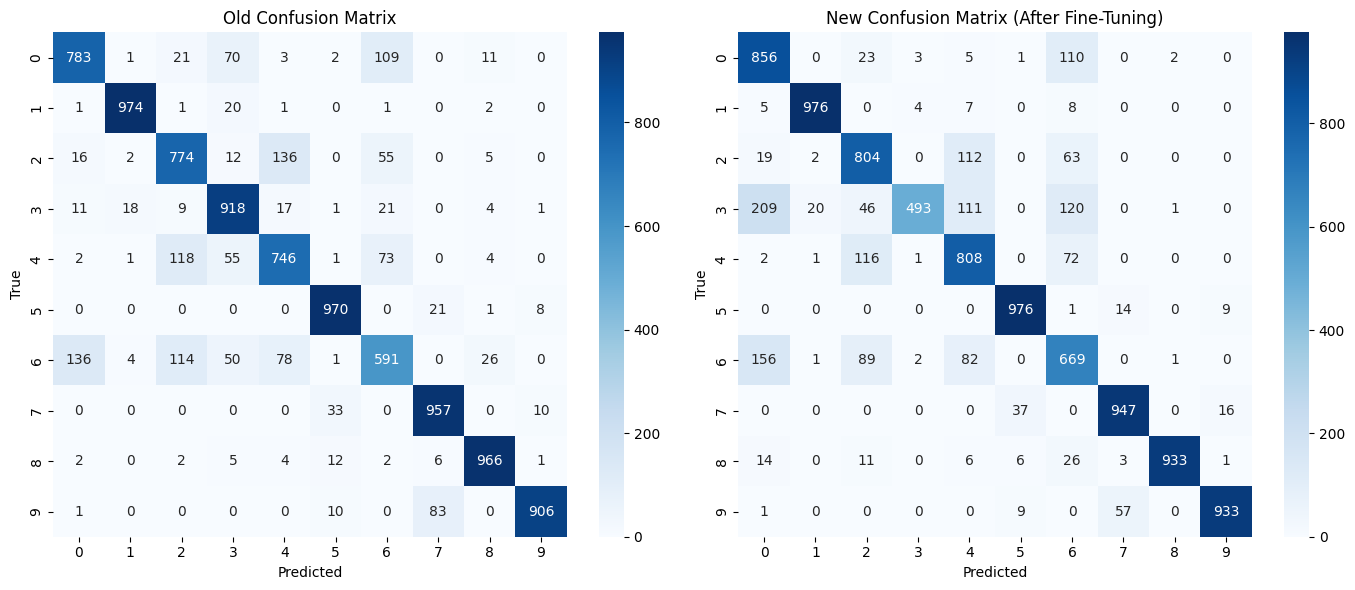

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


tuned_model.to(device)
tuned_model.eval()
all_labels = []
all_preds = []

with torch.inference_mode():
    for X, y in test_dataloader:  # full test set loader
        X, y = X.to(device), y.to(device)
        outputs = tuned_model(X)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confmat_tensor.cpu().numpy(), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Old Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")


cm_new = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Blues")
axes[1].set_title("New Confusion Matrix (After Fine-Tuning)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

# **◍ Step 9: Save and load best performing model.**

* `torch.save` - a function to save a whole PyTorch model or a model's state_dict().
* `torch.load` - a function to load in a saved PyTorch object.
* `torch.nn.Module.load_state_dict()` - a function to load a saved state_dict() into an existing model instance.

In [65]:
MODEL_PATH = Path("Models")
MODEL_PATH.mkdir(parents = True ,exist_ok = True)

# Create model save path
MODEL_NAME = "FashionModel.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=tuned_model.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: Models/FashionModel.pth


<a id="Import"></a>
<p style="background-color: #000000; font-family: 'Verdana', sans-serif; color: #FFFFFF; font-size: 160%; text-align: center; border-radius: 25px; padding: 12px 20px; margin-top: 20px; border: 2px solid transparent; background-image: linear-gradient(black, black), linear-gradient(45deg, #FF00FF, #00FFFF, #FFFF00, #FF4500); background-origin: border-box; background-clip: content-box, border-box; box-shadow: 0px 4px 20px rgba(255, 105, 180, 0.8);">
   Thanks & Upvote ❤️</p>